# **Diamond Price Prediction**
**Target:** `price` (Regression)  
**Models:** Linear Regression · Random Forest · XGBoost · Decision Tree Regressor · Stack Regressor (RF as meta-model)  
**Metrics:** MAE · RMSE · R²  
**Dataset Link:** <https://www.kaggle.com/datasets/shivam2503/diamonds/data>

### **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna

print('All libraries loaded successfully.')

All libraries loaded successfully.


### **Data Loading**

In [2]:
df = pd.read_csv('diamonds_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


|Feature|Description|
|-------|--------------|
|`price`| price in US dollars (\$326--\$18,823)|
|`carat` |weight of the diamond (0.2--5.01)|
|`cut` |quality of the cut (Fair, Good, Very Good, Premium, Ideal)|
|`color`| diamond colour, from J (worst) to D (best)|
|`clarity`|a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))|
|`x`|length in mm (0--10.74)|
|`y`|width in mm (0--58.9)|
|`z`|depth in mm (0--31.8)|
|`depth`|total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)|
|`table`|width of top of diamond relative to widest point (43--95)|

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [4]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
df.duplicated().sum()

np.int64(146)

In [6]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### **Preprocessing**

#### _Data Types_

In [7]:
print('Categorical columns:', df.select_dtypes(include='object').columns.tolist())
print('Numeric columns:    ', df.select_dtypes(include='number').columns.tolist())

for col in ['cut', 'color', 'clarity']:
    print('\n')
    print(f'  {col}: {df[col].unique()}')

Categorical columns: ['cut', 'color', 'clarity']
Numeric columns:     ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


  cut: <StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str


  color: <StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str


  clarity: <StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str


C:\Users\Kashyap Ramakrishnan\AppData\Local\Temp\ipykernel_30232\3281736930.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print('Categorical columns:', df.select_dtypes(include='object').columns.tolist())


#### _Null Values_

In [8]:
print('Null Count:\n',df.isnull().sum())
print('\n')
print('Null %:\n',(df.isnull().sum() / len(df) * 100).round(2))

Null Count:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


Null %:
 carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64


#### _Outlier Detection (Dimensions: x, y, z)_

In [9]:
#x, y, and z dimensions are length, width, and depth of the diamond and can't be zero.
print('Zero-dimension rows:')
print(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)].shape[0])

Zero-dimension rows:
19


We see that there are 19 records in the dataset which have `x` or `y` or  `z` features which are zero. Hence we have to remove these 19 records as a diamond cannot have any of these features as zero.

In [10]:
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(df.shape)

(53775, 10)


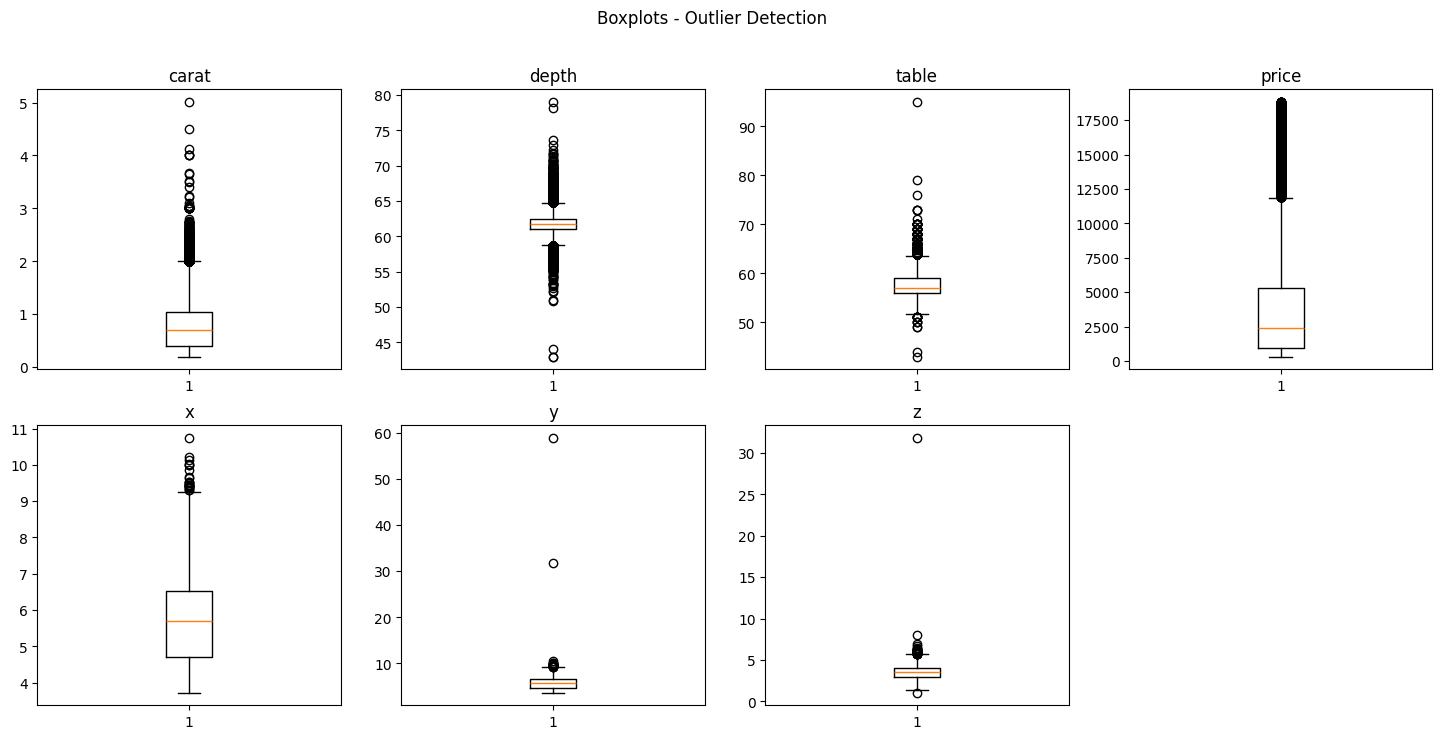

In [11]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

plt.figure(figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    plt.boxplot(df[col])
    plt.title(col)

plt.suptitle('Boxplots - Outlier Detection')
plt.show()

In [12]:
# Remove extreme outliers via IQR (3x) for y and z which have extreme values
for col in ['y', 'z']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR

    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(col, ": removed", before - len(df), "rows (bounds:", round(lower, 2), ",", round(upper, 2), ")")

print("\nFinal shape:", df.shape)

y : removed 2 rows (bounds: -0.74 , 12.0 )
z : removed 1 rows (bounds: -0.45 , 7.39 )

Final shape: (53772, 10)


#### _Normality Check_

In [ ]:
# Shapiro-Wilk test on a sample (max 5000 for speed)

sample = df.sample(min(5000, len(df)), random_state=42)

print("Column   Skew    p-value Normal")

for col in numeric_cols:
    skew = df[col].skew()
    p = round(stats.shapiro(sample[col])[1],4)
    
    if p > 0.05:
        normal = "Yes"
    else:
        normal = "No"
    
    print(col,'\t', abs(round(skew, 3)), '\t', p, '\t', normal)

Column   Skew    p-value Normal
carat 	 1.113 	 0.0 	 No
depth 	 0.114 	 0.0 	 No
table 	 0.792 	 0.0 	 No
price 	 1.618 	 0.0 	 No
x 	 0.397 	 0.0 	 No
y 	 0.391 	 0.0 	 No
z 	 0.392 	 0.0 	 No


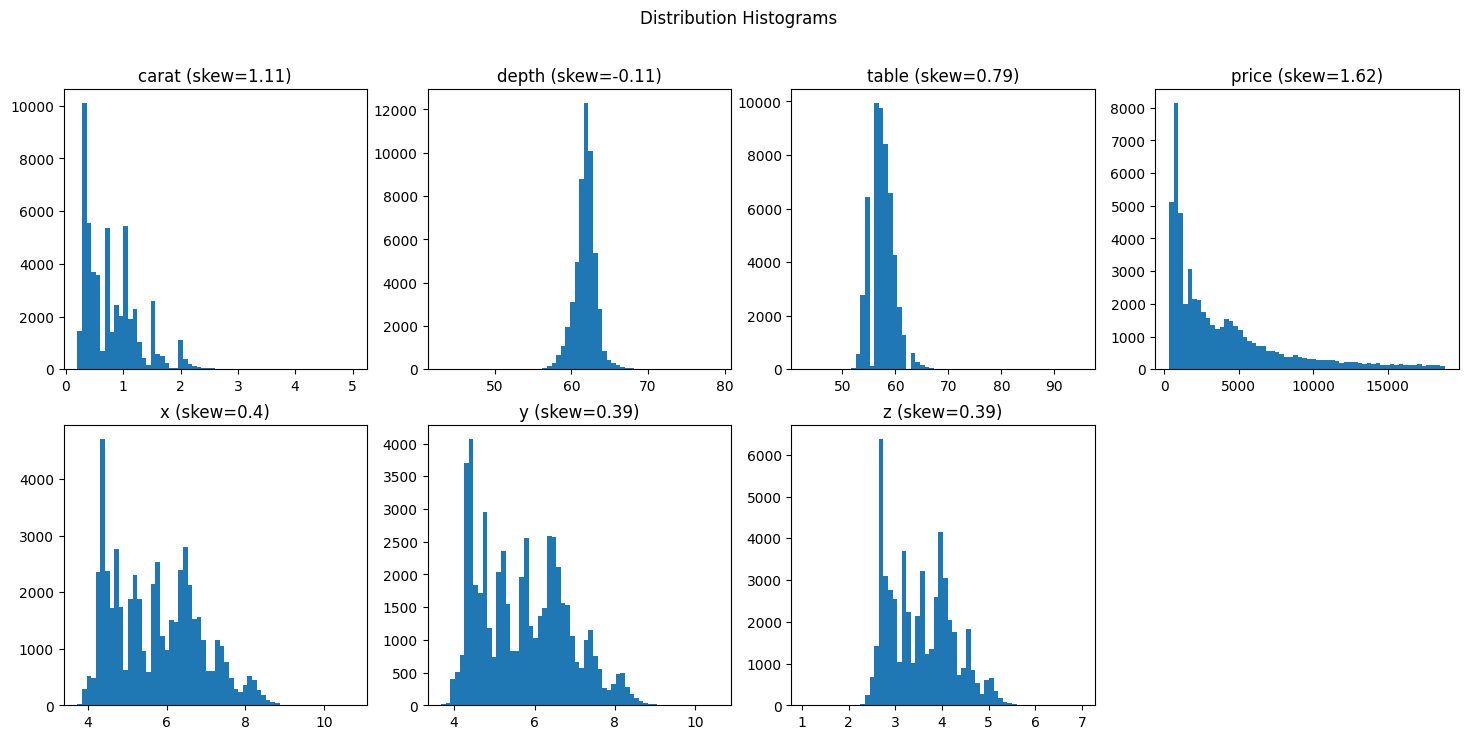

In [14]:
plt.figure(figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    plt.hist(df[col], bins=60)
    
    skew = df[col].skew()
    plt.title(col + " (skew=" + str(round(skew, 2)) + ")")

plt.suptitle('Distribution Histograms')
plt.show()

Let's see the target feature `price`'s distribution alone

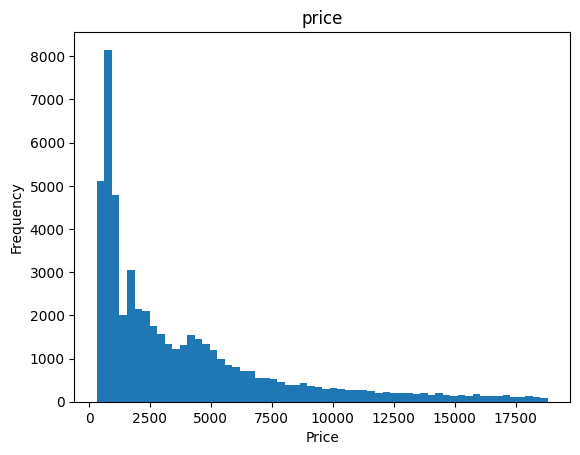

Number of outliers in price: 123


In [15]:
#Price Distribution and Outliers
plt.hist(df['price'], bins=60)
plt.title('price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3.0 * IQR
upper = Q3 + 3.0 * IQR
price_outliers = df[(df['price'] <= lower) | (df['price'] >= upper)]
print('Number of outliers in price:', len(price_outliers))

We can see that our target column ```price``` is heavily right-skewed. Hence we apply log tranformation to reduce outliers and also make it more normally distributed.

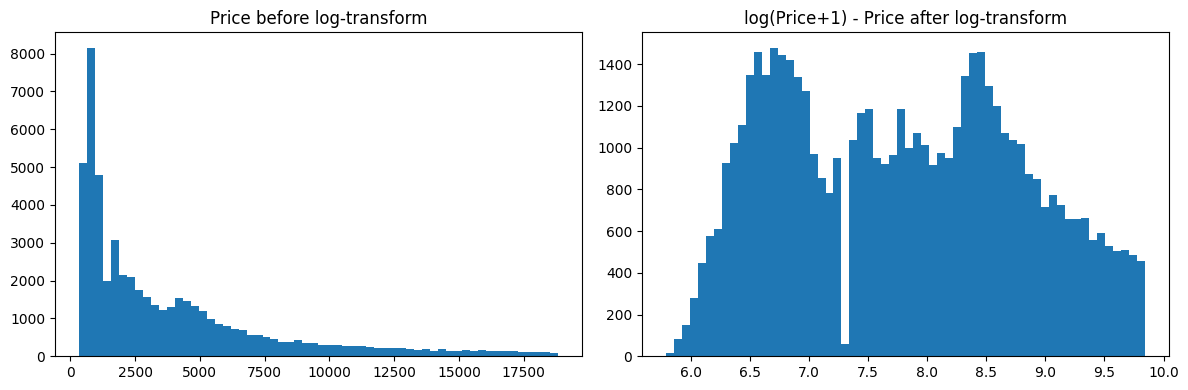

Number of outliers in log_price: 0


In [16]:
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=60)
plt.title('Price before log-transform')

plt.subplot(1, 2, 2)
plt.hist(df['log_price'], bins=60)
plt.title('log(Price+1) - Price after log-transform')

plt.tight_layout()
plt.show()

Q1_log = df['log_price'].quantile(0.25)
Q3_log = df['log_price'].quantile(0.75)
IQR_log = Q3_log - Q1_log

lower_log = Q1_log - 3.0 * IQR_log
upper_log = Q3_log + 3.0 * IQR_log

price_outliers = df[(df['log_price'] <= lower_log) | (df['log_price'] >= upper_log)]
print('Number of outliers in log_price:', len(price_outliers))

We can see that after applying log-transform, the ```price``` column has become normally distributed (```log_price```) and also all the outliers in the ```price``` feature (122 outliers) has been eliminated in the ```log_price``` feature.

#### _Encoding Categorical Variables_

In [17]:
# cut, color, clarity are ordinal features, so we must encode with ordering
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']      # D = best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df[['cut', 'color', 'clarity']] = enc.fit_transform(df[['cut', 'color', 'clarity']])

df[['cut', 'color', 'clarity']].head()

,cut,color,clarity
0,4.0,5.0,1.0
1,3.0,5.0,2.0
2,1.0,5.0,4.0
3,3.0,1.0,3.0
4,1.0,0.0,1.0


#### _Correlation Analysis & Feature Selection_

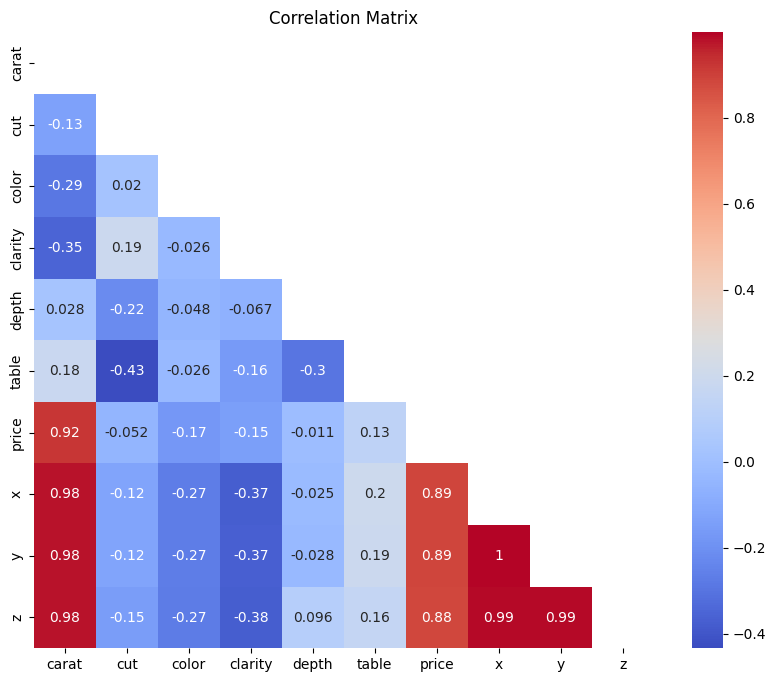

In [18]:
corr = df.drop(columns=['log_price']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, mask = np.triu(np.ones_like(corr, dtype=bool)), cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [19]:
# x, y, z are near-perfectly collinear with carat (correlation > 0.97)
# Drop x, y, z to remove multicollinearity — especially important for Linear Regression
print("Correlation with price:")
print(corr['price'].sort_values(ascending=False))

drop_cols = ['x', 'y', 'z', 'log_price']

features = [col for col in df.columns if col not in drop_cols and col != 'price']

print("\nSelected features:", features)

Correlation with price:
price      1.000000
carat      0.921542
y          0.888718
x          0.887127
z          0.881986
table      0.126662
depth     -0.011067
cut       -0.052230
clarity   -0.146075
color     -0.171709
Name: price, dtype: float64

Selected features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table']


#### **Final Feature List**
|Feature|Description|
|-------|--------------|
|`log_price`| log transformed values of price|
|`carat` |weight of the diamond (0.2--5.01)|
|`cut` |quality of the cut (Fair, Good, Very Good, Premium, Ideal)|
|`color`| diamond colour, from J (worst) to D (best)|
|`clarity`|a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))|
|`depth`|total depth percentage = `z / mean(x, y)` = $2 * z / (x + y)$ (43-79)|
|`table`|width of top of diamond relative to widest point (43--95)|

### **Train/Test Split & Scaling**

In [ ]:
X = df[features]
y = df['log_price']

# Step 1: split 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Step 2: split that 40% into 20% val and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (32263, 6)
Validation: (10754, 6)
Test: (10755, 6)


### **Model Training & Evaluation**

#### _Evaluate Function for printing model outputs_

In [21]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

results      = []
best_params  = {}   # store Optuna best params

#### _Linear Regression (No Tuning)_

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)
pred_lr = np.clip(pred_lr, 0, None)

results.append(evaluate('Linear Regression', y_test, pred_lr))

Linear Regression  MAE=0.28  RMSE=0.35  R²=0.8775


#### *Random Forest (Optuna Hyperparameter Tuned)*

In [ ]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators = trial.suggest_int('n_estimators', 100, 300),
        max_depth = trial.suggest_int('max_depth', 5, 30),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5),
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model, X_val, y_val,
        cv=3,
        scoring='neg_root_mean_squared_error'
    ).mean()

    return -score

rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=20)

best_params['rf'] = rf_study.best_params

print("\nRF Best Params:", rf_study.best_params)
print("RF Best RMSE:", round(rf_study.best_value, 2))

C:\Users\Kashyap Ramakrishnan\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-06 11:09:48,728] A new study created in memory with name: no-name-7359525c-4795-42ab-90fa-382ebdf8037b
[I 2026-04-06 11:09:51,285] Trial 0 finished with value: 0.11258286122699203 and parameters: {'n_estimators': 265, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.11258286122699203.
[I 2026-04-06 11:09:53,675] Trial 1 finished with value: 0.11257859562849977 and parameters: {'n_estimators': 243, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.11257859562849977.
[I 2026-04-06 11:09:56,025] Trial 2 finished with value: 0.11169107174630018 and parameters: {'n_estimators': 212, 'max_depth': 18, 'min_samples_s


RF Best Params: {'n_estimators': 133, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 1}
RF Best RMSE: 0.11


In [24]:
rf = RandomForestRegressor(**rf_study.best_params, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

results.append(evaluate('Random Forest (Optuna)', y_test, pred_rf))

Random Forest (Optuna)  MAE=0.08  RMSE=0.10  R²=0.9894


#### *XGBoost (Optuna Hyperparameter Tuned)*

In [ ]:
def xgb_objective(trial):
    model = XGBRegressor(
        n_estimators = trial.suggest_int('n_estimators', 100, 400),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2),
        max_depth = trial.suggest_int('max_depth', 3, 8),
        subsample = trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0),
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    score = cross_val_score(
        model, X_val, y_val,
        cv=3,
        scoring='neg_root_mean_squared_error'
    ).mean()

    return -score

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=25)

best_params['xgb'] = xgb_study.best_params

print("\nXGB Best Params:", xgb_study.best_params)
print("XGB Best RMSE:", round(xgb_study.best_value, 2))

[I 2026-04-06 11:10:20,556] A new study created in memory with name: no-name-f0f5b648-a685-4545-893d-9f123f9999b6
[I 2026-04-06 11:10:21,135] Trial 0 finished with value: 0.11143981464706972 and parameters: {'n_estimators': 258, 'learning_rate': 0.032337825375016255, 'max_depth': 4, 'subsample': 0.888312845308692, 'colsample_bytree': 0.8034059540015299}. Best is trial 0 with value: 0.11143981464706972.
[I 2026-04-06 11:10:22,059] Trial 1 finished with value: 0.18187130494029313 and parameters: {'n_estimators': 231, 'learning_rate': 0.013669766893462599, 'max_depth': 7, 'subsample': 0.7247825806318756, 'colsample_bytree': 0.7799018789680583}. Best is trial 0 with value: 0.11143981464706972.
[I 2026-04-06 11:10:22,826] Trial 2 finished with value: 0.10738387578885196 and parameters: {'n_estimators': 240, 'learning_rate': 0.14571466789272305, 'max_depth': 6, 'subsample': 0.7148766198806663, 'colsample_bytree': 0.7211156211251017}. Best is trial 2 with value: 0.10738387578885196.
[I 2026-0


XGB Best Params: {'n_estimators': 353, 'learning_rate': 0.04933768464098871, 'max_depth': 5, 'subsample': 0.7641785418748276, 'colsample_bytree': 0.9507493715374503}
XGB Best RMSE: 0.1


In [26]:
xgb = XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

results.append(evaluate('XGBoost (Optuna)', y_test, pred_xgb))

XGBoost (Optuna)  MAE=0.08  RMSE=0.10  R²=0.9901


#### _Decision Tree Regressor (Optuna Hyperparameter Tuned)_

In [27]:
from sklearn.tree import DecisionTreeRegressor

def dt_objective(trial):
    model = DecisionTreeRegressor(
        max_depth = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5),
        random_state=42
    )

    score = cross_val_score(
        model, X_val, y_val,
        cv=3,
        scoring='neg_root_mean_squared_error'
    ).mean()

    return -score

dt_study = optuna.create_study(direction='minimize')
dt_study.optimize(dt_objective, n_trials=20)

best_params['dt'] = dt_study.best_params

print("\nDT Best Params:", dt_study.best_params)
print("DT Best RMSE:", round(dt_study.best_value, 2))

[I 2026-04-06 11:10:42,337] A new study created in memory with name: no-name-f027c76c-d2e8-4e60-9b1d-d5ea16979f1f
[I 2026-04-06 11:10:42,435] Trial 0 finished with value: 0.13298388043617085 and parameters: {'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.13298388043617085.
[I 2026-04-06 11:10:42,473] Trial 1 finished with value: 0.1391439849351924 and parameters: {'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.13298388043617085.
[I 2026-04-06 11:10:42,526] Trial 2 finished with value: 0.13353581485330657 and parameters: {'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.13298388043617085.
[I 2026-04-06 11:10:42,554] Trial 3 finished with value: 0.170188726005799 and parameters: {'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.13298388043617085.
[I 2026-04-06 11:10:42,607] Trial 4 finished with value: 0.


DT Best Params: {'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 5}
DT Best RMSE: 0.13


In [28]:
dt = DecisionTreeRegressor(**dt_study.best_params, random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

results.append(evaluate('Decision Tree (Optuna)', y_test, pred_dt))

Decision Tree (Optuna)  MAE=0.09  RMSE=0.11  R²=0.9872


#### *Weighted Ensemble (Random Forest as Meta-Model)*

Stack the base-model predictions as new features, then train a Random Forest meta-model on them.

In [29]:
best_dt = DecisionTreeRegressor(**dt_study.best_params, random_state=42)
best_rf = RandomForestRegressor(**rf_study.best_params, random_state=42)
best_xgb = XGBRegressor(**xgb_study.best_params,random_state=42)
best_lr = LinearRegression()

best_lr.fit(X_train_scaled, y_train)
best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9507493715374503
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [30]:
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([('scaler', StandardScaler()), ('lr', best_lr)])

stack_model = StackingRegressor(
    estimators=[
        ('lr', lr_pipeline),
        ('dt', best_dt),
        ('xgb', best_xgb)
        ],
    final_estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    cv=5
)


stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('dt', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [31]:
pred_stack = stack_model.predict(X_test)

pred_stack = np.clip(pred_stack, 0, None)

stack_res = evaluate('Stacking Model', y_test, pred_stack)
results.append(stack_res)

Stacking Model  MAE=0.08  RMSE=0.11  R²=0.9891


In [32]:
lr_res  = evaluate('Linear Regression', y_test, pred_lr)
dt_res  = evaluate('Decision Tree', y_test, pred_dt)
rf_res  = evaluate('Random Forest', y_test, pred_rf)
xgb_res = evaluate('XGBoost', y_test, pred_xgb)
stack_res = evaluate('Stacking Model', y_test, pred_stack)

Linear Regression  MAE=0.28  RMSE=0.35  R²=0.8775
Decision Tree  MAE=0.09  RMSE=0.11  R²=0.9872
Random Forest  MAE=0.08  RMSE=0.10  R²=0.9894
XGBoost  MAE=0.08  RMSE=0.10  R²=0.9901
Stacking Model  MAE=0.08  RMSE=0.11  R²=0.9891


### **Results Summary**

In [33]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).set_index('Model')
print('\nModel Comparison')
print(results_df.to_string())


Model Comparison
                         MAE  RMSE      R2
Model                                     
XGBoost (Optuna)        0.08  0.10  0.9901
Random Forest (Optuna)  0.08  0.10  0.9894
Stacking Model          0.08  0.11  0.9891
Decision Tree (Optuna)  0.09  0.11  0.9872
Linear Regression       0.28  0.35  0.8775


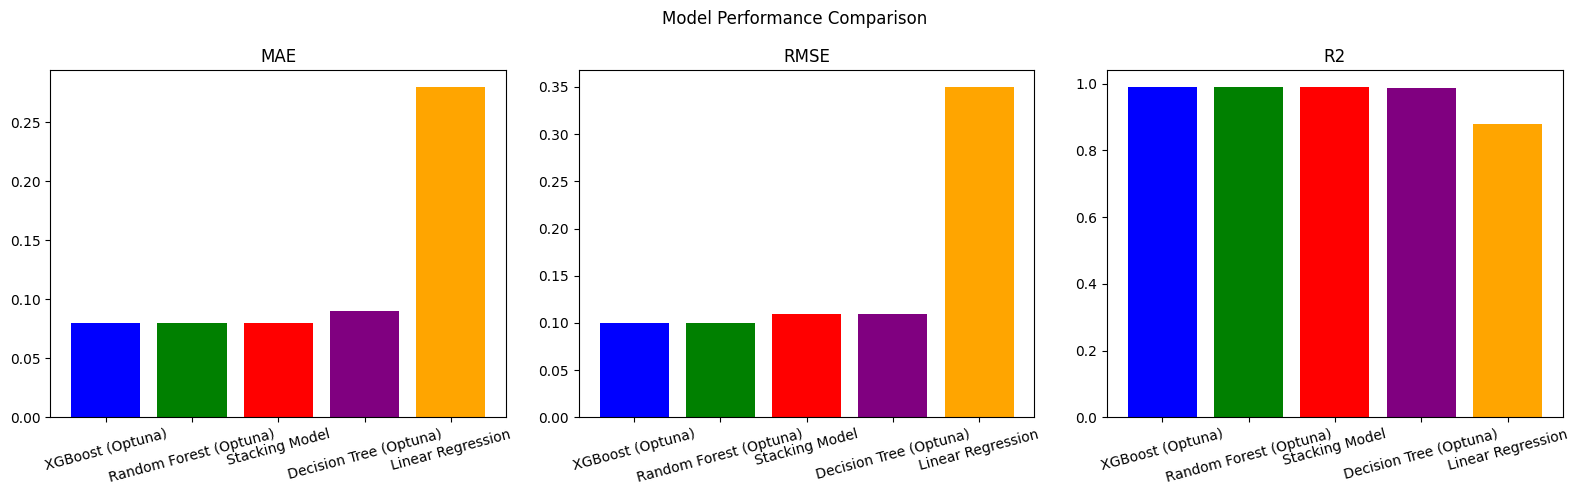

In [34]:
metrics = ['MAE', 'RMSE', 'R2']

# one color per model
colors = ['blue', 'green', 'red', 'purple', 'orange'][:len(results_df)]

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    plt.bar(results_df.index, results_df[metric], color=colors)
    plt.title(metric)
    plt.xticks(rotation=15)

plt.suptitle('Model Performance Comparison')
plt.tight_layout()
plt.show()

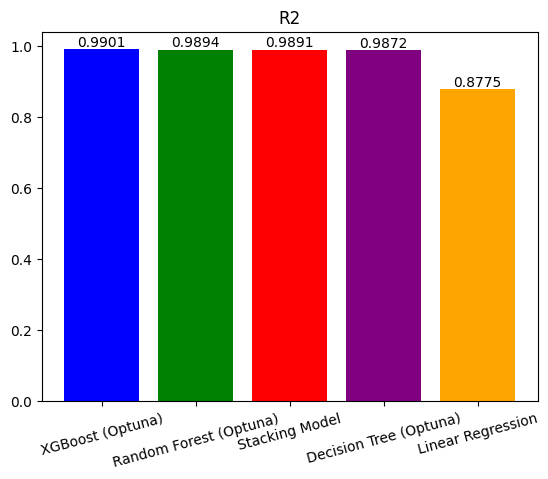

In [35]:
plt.bar(results_df.index, results_df['R2'], color=colors)

for i, val in enumerate(results_df['R2']):
    plt.text(i, val, f'{val:.4f}', ha='center', va='bottom')

plt.title('R2')
plt.xticks(rotation=15)
plt.show()

### **Residual & Prediction Analysis**

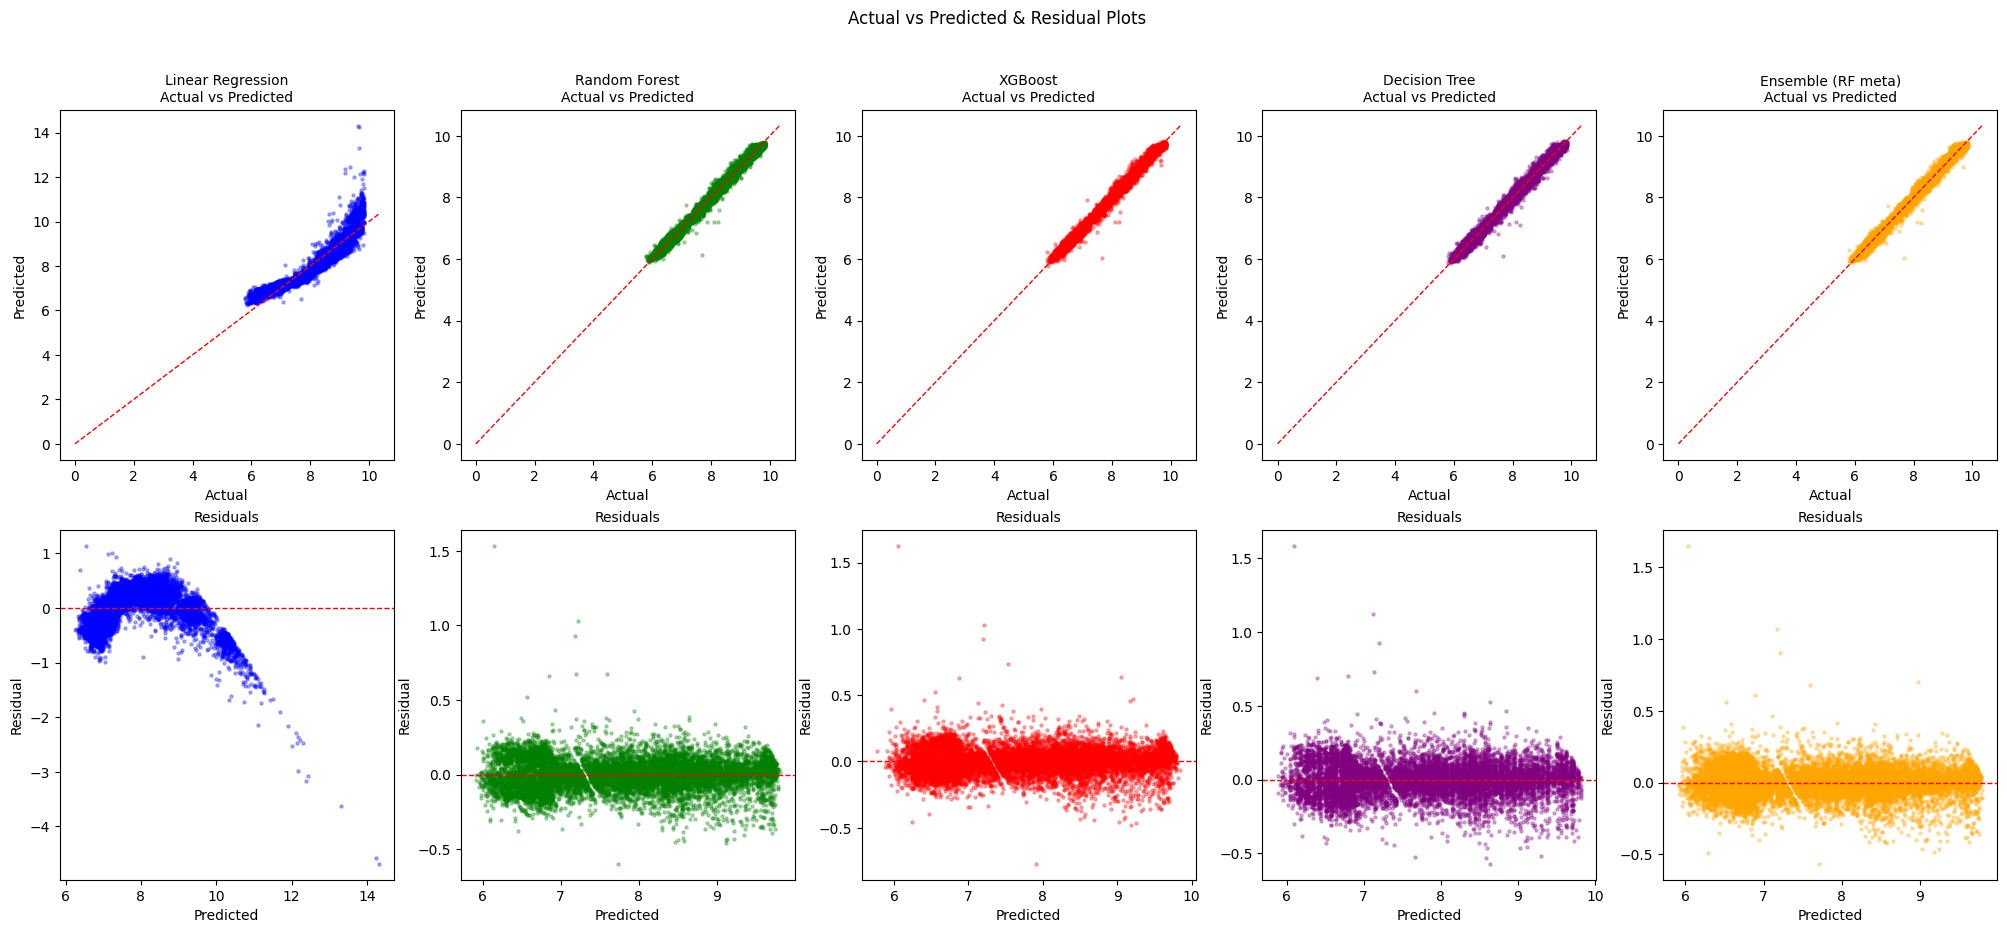

In [36]:
preds = {
    'Linear Regression': pred_lr,
    'Random Forest':     pred_rf,
    'XGBoost':           pred_xgb,
    'Decision Tree':     pred_dt,
    'Ensemble (RF meta)':pred_stack
}

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, (name, pred) in enumerate(preds.items()):
    residuals = y_test.values - pred

    # Actual vs Predicted
    axes[0, i].scatter(y_test, pred, alpha=0.3, s=5, color=colors[i])
    lim = [0, y_test.max() * 1.05]
    axes[0, i].plot(lim, lim, 'r--', lw=1)
    axes[0, i].set_title(f'{name}\nActual vs Predicted', fontsize=10)
    axes[0, i].set_xlabel('Actual')
    axes[0, i].set_ylabel('Predicted')

    # Residuals
    axes[1, i].scatter(pred, residuals, alpha=0.3, s=5, color=colors[i])
    axes[1, i].axhline(0, color='red', lw=1, linestyle='--')
    axes[1, i].set_title(f'Residuals', fontsize=10)
    axes[1, i].set_xlabel('Predicted')
    axes[1, i].set_ylabel('Residual')

plt.suptitle('Actual vs Predicted & Residual Plots')
plt.show()

This graph compares five regression models, revealing that Linear Regression completely fails to capture the underlying non-linear pattern in the data. The tree-based ensembles (like XGBoost and the RF Meta Ensemble) perform significantly better, with predictions clustering tightly around the ideal accuracy line.

$Residual = Actual\_Value - Predicted\_Value$ 

Mathematically, it is usually written as:

$e = y - \hat{y}$

The residuals in the new graph form a consistent, horizontal band around zero, proving that your log transformation successfully stabilized the error variance and cured the heteroscedasticity.

### **Feature Importance (Random Forest)**

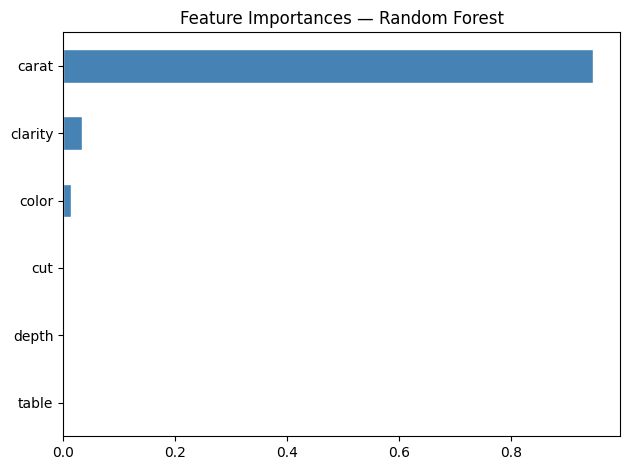

In [37]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.xlabel('Importance')
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

### **Final Summary**

In [38]:
best = results_df['R2'].idxmax()
print('Final Results')
print(results_df.sort_values('R2', ascending=False).to_string())
print(f'\nBest model: {best}  (R² = {results_df.loc[best, "R2"]})')

Final Results
                         MAE  RMSE      R2
Model                                     
XGBoost (Optuna)        0.08  0.10  0.9901
Random Forest (Optuna)  0.08  0.10  0.9894
Stacking Model          0.08  0.11  0.9891
Decision Tree (Optuna)  0.09  0.11  0.9872
Linear Regression       0.28  0.35  0.8775

Best model: XGBoost (Optuna)  (R² = 0.9901)


##### **Final Interpretations**

| Model                  | Interpretation                                                                              |
| ---------------------- | --------------------------------------------------------------------------------------------|
| XGBoost (Optuna)       | Best performer. Optimized boosting captures complex patterns best.                          |
| Stacking Model         | Combines multiple models. Performance close to RF and XGBoost. Useful if you want stability.|
| Random Forest (Optuna) | Ensemble of trees improves predictions significantly.                                       |
| Decision Tree (Optuna) | Single optimized tree. Overfitting risk is higher.                                          |
| Linear Regression      | Underperforms compared to optimized models.                                                 |


### **Unseen Data Prediction**

In [39]:
import pandas as pd
import numpy as np

#INPUT
carat = float(input("Enter carat: "))
depth = float(input("Enter depth: "))
table = float(input("Enter table: "))

cut = input("Enter cut (Fair, Good, Very Good, Premium, Ideal): ")
color = input("Enter color (D, E, F, G, H, I, J): ")
clarity = input("Enter clarity (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF): ")

#CREATE DATAFRAME
new_df = pd.DataFrame([{
    'carat': carat,
    'depth': depth,
    'table': table,
    'cut': cut,
    'color': color,
    'clarity': clarity
}])

#ENCODING (IMPORTANT: enc must already be fitted on training data)
new_df[['cut', 'color', 'clarity']] = enc.transform(
    new_df[['cut', 'color', 'clarity']]
)

#ALIGN COLUMNS
new_df = new_df.reindex(columns=X_train.columns, fill_value=0)

print(new_df)  # ADD THIS — verify your input before predicting

#PREDICTION
models = {
    'Linear Regression': best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'Stacking': stack_model
}

#Convert each log-space prediction back to price-space first, then combine
xgb_price   = np.expm1(best_xgb.predict(new_df)[0])
rf_price    = np.expm1(best_rf.predict(new_df)[0])
stack_price = np.expm1(stack_model.predict(new_df)[0])

print("\nPredicted Prices:")
weighted_pred = 0.8*xgb_price + 0.15*stack_price + 0.05*rf_price  #weighted average of XGB, RF and Stacking
print(f"{'XGBoost':<15}: {xgb_price:.2f}")
print(f"{'Random Forest':<15}: {rf_price:.2f}")
print(f"{'Stacking':<15}: {stack_price:.2f}")
print(f"{'Weighted Average'}: {weighted_pred:.2f}")

   carat  cut  color  clarity  depth  table
0    0.8  3.0    2.0      2.0   61.5   58.0

Predicted Prices:
XGBoost        : 2666.67
Random Forest  : 2734.64
Stacking       : 2755.15
Weighted Average: 2683.34
